This notebook shows how to compute word embeddings and use them for sentiment analysis.

To implement sentiment analysis, you can go beyond counting the number of positive words and negative words.
You can find a way to represent each word numerically, by a vector.
The vector could then represent syntactic (i.e. parts of speech) and semantic (i.e. meaning) structures.
In this assignment, you will explore a classic way of generating word embeddings or representations.

You will implement a famous model called the continuous bag of words (CBOW) model.
By completing this assignment you will:

Train word vectors from scratch.
Learn how to create batches of data.
Understand how backpropagation works.
Plot and visualize your learned word vectors.
Knowing how to train these models will give you a better understanding of word vectors, which are building blocks to many applications in natural language processing.

In [1]:
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
import torch

In [2]:
from utils2 import sigmoid, get_batches, compute_pca, get_dict

Implementing via the methods manul NN or fit it into a NN with the lib implementations

In [3]:
import torch.nn as nn
import torch.optim as optim
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import scipy
import os
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from tqdm.auto import tqdm

In [8]:
# Download sentence tokenizer
nltk.data.path.append('.')

In [9]:
import re #regex used to for formatting the dataset in a given way
# ML_Jupyter/NLP/Word Embedding with NN/shakespeare.txt
with open('shakespeare.txt') as f:
    data = f.read()
    
data = re.sub(r'[,!?;-]' , '.' , data) #  Punktuations are replaced by .
data = nltk.word_tokenize(data) #  Tokenize string to words

data = [ ch.lower() for ch in data if ch.isalpha() or ch == '.'] #  Lower case and drop non-alphabetical token
print("Number of token: " , len(data) , '\n' , data[:15])



Number of token:  60976 
 ['o', 'for', 'a', 'muse', 'of', 'fire', '.', 'that', 'would', 'ascend', 'the', 'brightest', 'heaven', 'of', 'invention']


In [11]:
fdist = nltk.FreqDist(word for word in data)
print("Size of vocabulary: ",len(fdist) )
print("Most frequent tokens: ",fdist.most_common(20) ) # print the 20 most frequent words and their freq.

Size of vocabulary:  5775
Most frequent tokens:  [('.', 9630), ('the', 1521), ('and', 1394), ('i', 1257), ('to', 1159), ('of', 1093), ('my', 857), ('that', 781), ('in', 770), ('a', 752), ('you', 748), ('is', 630), ('not', 559), ('for', 467), ('it', 460), ('with', 441), ('his', 434), ('but', 417), ('me', 417), ('your', 397)]


### Mapping words to indices and indices to words
##### use a helper function to create a dictionary that maps words to indices and indices to words.

get_dict from the utils file


In [13]:
# def get_dict(data):
#     """
#     Input:
#         K: the number of negative samples
#         data: the data you want to pull from
#         indices: a list of word indices
#     Output:
#         word_dict: a dictionary with the weighted probabilities of each word
#         word2Ind: returns dictionary mapping the word to its index
#         Ind2Word: returns dictionary mapping the index to its word
#     """
#     #
# #     words = nltk.word_tokenize(data)
#     words = sorted(list(set(data)))
#     n = len(words)
#     idx = 0
#     # return these correctly
#     word2Ind = {}
#     Ind2word = {}
#     for k in words:
#         word2Ind[k] = idx
#         Ind2word[idx] = k
#         idx += 1
#     return word2Ind, Ind2word
#THIS gives a mapping based on word and index given one param return the counterpart to it

In [14]:
word2Ind, Ind2word = get_dict(data)
V = len(word2Ind)
print("Size of vocabulary: ", V)

Size of vocabulary:  5775


In [15]:
# example of word to index mapping
print("Index of the word 'new' :  ",word2Ind['new'] )
print("Word which has index 2743:  ",Ind2word[2743] )

Index of the word 'new' :   3324
Word which has index 2743:   kinds


Training the Model
Initializing the model
You will now initialize two matrices and two vectors.

The first matrix (W1) is of dimension N*V, where 
V is the number of words in your vocabulary and 
N is the dimension of your word vector.
The second matrix (W2) is of dimension V*N.
Vector b1 has dimensions N
Vector b2 has dimensions V.
b1 and b2 are the bias vectors of the linear layers from matrices and.
The overall structure of the model will look as in Figure 1, but at this stage we are just initializing the parameters.

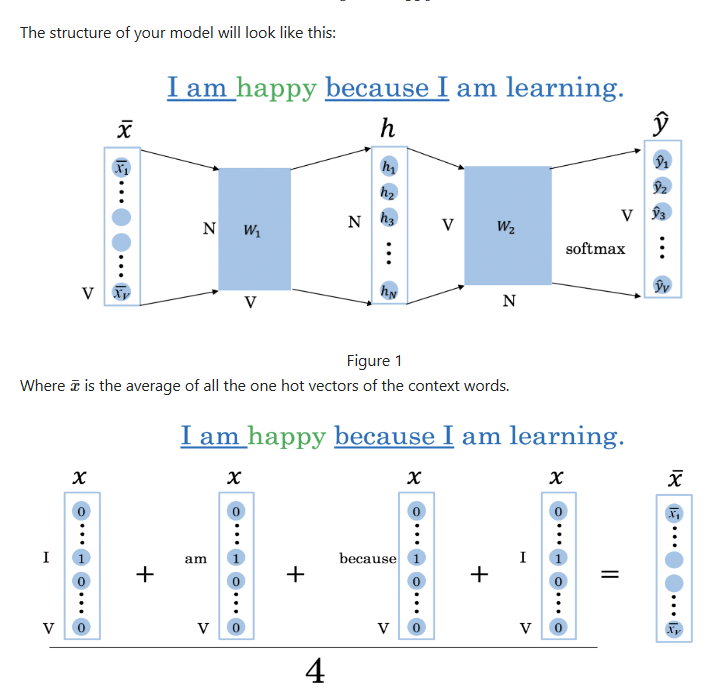

In [17]:
def initialize_model(N,V, random_seed=1):
    '''
    Inputs: 
        N:  dimension of hidden vector 
        V:  dimension of vocabulary
        random_seed: random seed for consistent results in the unit tests
     Outputs: 
        W1, W2, b1, b2: initialized weights and biases
    '''
    
    np.random.seed(random_seed)
    # W1 has shape (N,V)
    W1 = np.random.rand(N,V)
    # W2 has shape (V,N)
    W2 = np.random.rand(V,N)
    # b1 has shape (N,1)
    b1 = np.random.rand(N,1)
    # b2 has shape (V,1)
    b2 = np.random.rand(V,1)

    return W1, W2, b1, b2

In [18]:
# Test your function example.
tmp_N = 4
tmp_V = 10
tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(tmp_N,tmp_V)
assert tmp_W1.shape == ((tmp_N,tmp_V))
assert tmp_W2.shape == ((tmp_V,tmp_N))
print(f"tmp_W1.shape: {tmp_W1.shape}")
print(f"tmp_W2.shape: {tmp_W2.shape}")
print(f"tmp_b1.shape: {tmp_b1.shape}")
print(f"tmp_b2.shape: {tmp_b2.shape}")

tmp_W1.shape: (4, 10)
tmp_W2.shape: (10, 4)
tmp_b1.shape: (4, 1)
tmp_b2.shape: (10, 1)


In [19]:
def softmax(z):
    
    e_z = np.exp(z)
    yhat = e_z/np.sum(e_z,axis=0)
    
    return yhat

In [20]:
# Test the function
tmp = np.array([[1,2,3],
                [1,1,1]
               ])
tmp_sm = softmax(tmp)
display(tmp_sm)

array([[0.5       , 0.73105858, 0.88079708],
       [0.5       , 0.26894142, 0.11920292]])

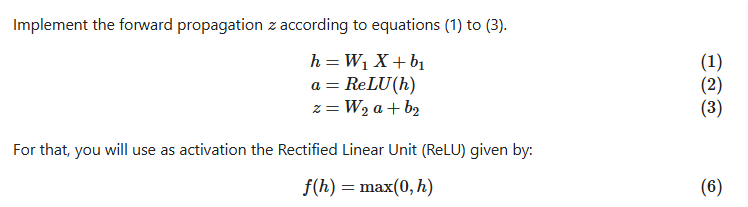

In [21]:
def forward_prop(x, W1, W2, b1, b2):
    '''
    Inputs: 
        x:  average one hot vector for the context 
        W1, W2, b1, b2:  matrices and biases to be learned
     Outputs: 
        z:  output score vector
    '''
    
    # Calculate h
    h = np.dot(W1,x)+b1
    
    # Apply the relu on h (store result in h)
    h = np.maximum(0,h)
    
    # Calculate z
    z = np.dot(W2,h)+b2

    return z, h

In [22]:
# Test the function

# Create some inputs
tmp_N = 2
tmp_V = 3
tmp_x = np.array([[0,1,0]]).T
tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(N=tmp_N,V=tmp_V, random_seed=1)

print(f"x has shape {tmp_x.shape}")
print(f"N is {tmp_N} and vocabulary size V is {tmp_V}")

# call function
tmp_z, tmp_h = forward_prop(tmp_x, tmp_W1, tmp_W2, tmp_b1, tmp_b2)
print("call forward_prop")
print()
# Look at output
print(f"z has shape {tmp_z.shape}")
print("z has values:")
print(tmp_z)

print()

print(f"h has shape {tmp_h.shape}")
print("h has values:")
print(tmp_h)

x has shape (3, 1)
N is 2 and vocabulary size V is 3
call forward_prop

z has shape (3, 1)
z has values:
[[0.55379268]
 [1.58960774]
 [1.50722933]]

h has shape (2, 1)
h has values:
[[0.92477674]
 [1.02487333]]


Cross Entropy Loss function

In [23]:
def compute_cost(y, yhat, batch_size):
    # cost function 
    logprobs = np.multiply(np.log(yhat),y) + np.multiply(np.log(1 - yhat), 1 - y)
    cost = - 1/batch_size * np.sum(logprobs)
    cost = np.squeeze(cost)
    return cost

In [24]:
# Test the function
tmp_C = 2
tmp_N = 50
tmp_batch_size = 4
tmp_word2Ind, tmp_Ind2word = get_dict(data)
tmp_V = len(word2Ind)

tmp_x, tmp_y = next(get_batches(data, tmp_word2Ind, tmp_V,tmp_C, tmp_batch_size))
        
print(f"tmp_x.shape {tmp_x.shape}")
print(f"tmp_y.shape {tmp_y.shape}")

tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(tmp_N,tmp_V)

print(f"tmp_W1.shape {tmp_W1.shape}")
print(f"tmp_W2.shape {tmp_W2.shape}")
print(f"tmp_b1.shape {tmp_b1.shape}")
print(f"tmp_b2.shape {tmp_b2.shape}")

tmp_z, tmp_h = forward_prop(tmp_x, tmp_W1, tmp_W2, tmp_b1, tmp_b2)
print(f"tmp_z.shape: {tmp_z.shape}")
print(f"tmp_h.shape: {tmp_h.shape}")

tmp_yhat = softmax(tmp_z)
print(f"tmp_yhat.shape: {tmp_yhat.shape}")

tmp_cost = compute_cost(tmp_y, tmp_yhat, tmp_batch_size)
print("call compute_cost")
print(f"tmp_cost {tmp_cost:.4f}")

tmp_x.shape (5775, 4)
tmp_y.shape (5775, 4)
tmp_W1.shape (50, 5775)
tmp_W2.shape (5775, 50)
tmp_b1.shape (50, 1)
tmp_b2.shape (5775, 1)
tmp_z.shape: (5775, 4)
tmp_h.shape: (50, 4)
tmp_yhat.shape: (5775, 4)
call compute_cost
tmp_cost 11.4095


### NOW TRAINING THE MODEL WITH BACKPROPOGATION

In [30]:
def back_prop(x, yhat, y, h, W1, W2, b1, b2, batch_size):
    '''
    Inputs: 
        x:  average one hot vector for the context 
        yhat: prediction (estimate of y)
        y:  target vector
        h:  hidden vector (see eq. 1)
        W1, W2, b1, b2:  matrices and biases  
        batch_size: batch size 
     Outputs: 
        grad_W1, grad_W2, grad_b1, grad_b2:  gradients of matrices and biases   
    '''    
    # Compute l1 as W2^T (Yhat - Y)
    # Re-use it whenever you see W2^T (Yhat - Y) used to compute a gradient
    l1 = np.dot(W2.T,(yhat-y))
    # Apply relu to l1
    l1 = np.maximum(0,l1)
    # Compute the gradient of W1
    
    grad_W1 = (1/batch_size)*np.dot(l1,x.T) 
    # Compute the gradient of W2
    grad_W2 = (1/batch_size)*np.dot(yhat-y,h.T)
    # Compute the gradient of b1
    grad_b1 = np.sum((1/batch_size)*np.dot(l1,x.T),axis=1,keepdims=True)
    # Compute the gradient of b2
    grad_b2 = np.sum((1/batch_size)*np.dot(yhat-y,h.T),axis=1,keepdims=True)
    
    return grad_W1, grad_W2, grad_b1, grad_b2

In [31]:
def back_prop(x, yhat, y, h, W1, W2, b1, b2, batch_size):
    # 1. Compute the error signal for the output layer
    # l1 is the gradient backpropagated to the hidden layer
    l1 = np.dot(W2.T, (yhat - y))
    
    # 2. Apply ReLU element-wise
    l1 = np.maximum(0, l1)
    
    # 3. Compute weight gradients
    grad_W1 = (1/batch_size) * np.dot(l1, x.T) 
    grad_W2 = (1/batch_size) * np.dot(yhat - y, h.T)
    
    # 4. Compute bias gradients (Sum the error across the batch and average it)
    grad_b1 = (1/batch_size) * np.sum(l1, axis=1, keepdims=True)
    grad_b2 = (1/batch_size) * np.sum(yhat - y, axis=1, keepdims=True)
    
    return grad_W1, grad_W2, grad_b1, grad_b2

In [32]:
# Test the function
tmp_C = 2
tmp_N = 50
tmp_batch_size = 4
tmp_word2Ind, tmp_Ind2word = get_dict(data)
tmp_V = len(word2Ind)

# get a batch of data
tmp_x, tmp_y = next(get_batches(data, tmp_word2Ind, tmp_V,tmp_C, tmp_batch_size))

print("get a batch of data")
print(f"tmp_x.shape {tmp_x.shape}")
print(f"tmp_y.shape {tmp_y.shape}")

print()
print("Initialize weights and biases")
tmp_W1, tmp_W2, tmp_b1, tmp_b2 = initialize_model(tmp_N,tmp_V)

print(f"tmp_W1.shape {tmp_W1.shape}")
print(f"tmp_W2.shape {tmp_W2.shape}")
print(f"tmp_b1.shape {tmp_b1.shape}")
print(f"tmp_b2.shape {tmp_b2.shape}")

print()
print("Forwad prop to get z and h")
tmp_z, tmp_h = forward_prop(tmp_x, tmp_W1, tmp_W2, tmp_b1, tmp_b2)
print(f"tmp_z.shape: {tmp_z.shape}")
print(f"tmp_h.shape: {tmp_h.shape}")

print()
print("Get yhat by calling softmax")
tmp_yhat = softmax(tmp_z)
print(f"tmp_yhat.shape: {tmp_yhat.shape}")

tmp_m = (2*tmp_C)
tmp_grad_W1, tmp_grad_W2, tmp_grad_b1, tmp_grad_b2 = back_prop(tmp_x, tmp_yhat, tmp_y, tmp_h, tmp_W1, tmp_W2, tmp_b1, tmp_b2, tmp_batch_size)

print()
print("call back_prop")
print(f"tmp_grad_W1.shape {tmp_grad_W1.shape}")
print(f"tmp_grad_W2.shape {tmp_grad_W2.shape}")
print(f"tmp_grad_b1.shape {tmp_grad_b1.shape}")
print(f"tmp_grad_b2.shape {tmp_grad_b2.shape}")

get a batch of data
tmp_x.shape (5775, 4)
tmp_y.shape (5775, 4)

Initialize weights and biases
tmp_W1.shape (50, 5775)
tmp_W2.shape (5775, 50)
tmp_b1.shape (50, 1)
tmp_b2.shape (5775, 1)

Forwad prop to get z and h
tmp_z.shape: (5775, 4)
tmp_h.shape: (50, 4)

Get yhat by calling softmax
tmp_yhat.shape: (5775, 4)

call back_prop
tmp_grad_W1.shape (50, 5775)
tmp_grad_W2.shape (5775, 50)
tmp_grad_b1.shape (50, 1)
tmp_grad_b2.shape (5775, 1)


Now that you have implemented a function to compute the gradients, you will implement batch gradient descent over your training set.

Hint: For that, you will use initialize_model and the back_prop functions which you just created (and the compute_cost function). You can also use the provided get_batches helper function:

for x, y in get_batches(data, word2Ind, V, C, batch_size):

In [33]:
def gradient_descent(data, word2Ind, N, V, num_iters, alpha=0.03):
    
    '''
    This is the gradient_descent function
    
      Inputs: 
        data:      text
        word2Ind:  words to Indices
        N:         dimension of hidden vector  
        V:         dimension of vocabulary 
        num_iters: number of iterations  
     Outputs: 
        W1, W2, b1, b2:  updated matrices and biases   

    '''
    W1, W2, b1, b2 = initialize_model(N,V, random_seed=282)
    batch_size = 128
    iters = 0
    C = 2
    for x, y in get_batches(data, word2Ind, V, C, batch_size):
        # Get z and h
        z, h = forward_prop(x, W1, W2, b1, b2)
        # Get yhat
        yhat = softmax(z)
        # Get cost
        cost = compute_cost(y, yhat, batch_size)
        if ( (iters+1) % 10 == 0):
            print(f"iters: {iters + 1} cost: {cost:.6f}")
        # Get gradients
        grad_W1, grad_W2, grad_b1, grad_b2 = back_prop(x, yhat, y, h, W1, W2, b1, b2, batch_size)
        
        # Update weights and biases
        W1 -= alpha*grad_W1 
        W2 -= alpha*grad_W2
        b1 -= alpha*grad_b1
        b2 -= alpha*grad_b2
        
        iters += 1 
        if iters == num_iters: 
            break
        if iters % 100 == 0:
            alpha *= 0.66
            
    return W1, W2, b1, b2


In [34]:
C = 2
N = 50
word2Ind, Ind2word = get_dict(data)
V = len(word2Ind)
num_iters = 150
print("Call gradient_descent")
W1, W2, b1, b2 = gradient_descent(data, word2Ind, N, V, num_iters)

Call gradient_descent
iters: 10 cost: 0.569737
iters: 20 cost: 0.106251
iters: 30 cost: 0.058094
iters: 40 cost: 0.039949
iters: 50 cost: 0.030436
iters: 60 cost: 0.024582
iters: 70 cost: 0.020616
iters: 80 cost: 0.017752
iters: 90 cost: 0.015587
iters: 100 cost: 0.013892
iters: 110 cost: 0.012919
iters: 120 cost: 0.012113
iters: 130 cost: 0.011401
iters: 140 cost: 0.010768
iters: 150 cost: 0.010202


In [36]:
from matplotlib import pyplot
%config InlineBackend.figure_format = 'svg'
words = ['king', 'queen','lord','man', 'woman','dog','wolf',
         'rich','happy','sad']

embs = (W1.T + W2)/2.0
 
# given a list of words and the embeddings, it returns a matrix with all the embeddings
idx = [word2Ind[word] for word in words]
X = embs[idx, :]
print(X.shape, idx)  # X.shape:  Number of words of dimension N each 

(10, 50) [2744, 3949, 2960, 3022, 5672, 1452, 5671, 4189, 2315, 4276]


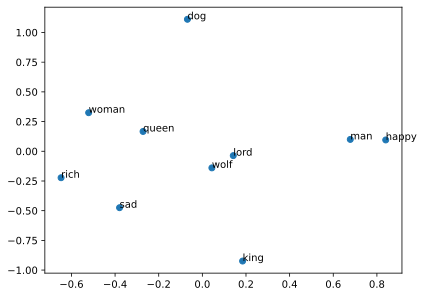

In [37]:
result= compute_pca(X, 4)
pyplot.scatter(result[:, 3], result[:, 1])
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 3], result[i, 1]))
pyplot.show()

#### Vector Visualization (PCA): Look at the plot generated at the end. If the model is "working as intended," words like 'king' and 'lord' or 'man' and 'woman' should appear closer to each other than to a word like 'dog'.

#### The Semantic Test: Because similar words now have similar dense vectors, the model has captured the "meaning" of the Shakespearean text.

In [38]:
def predict_center_word(context_words, word2Ind, Ind2word, V, W1, W2, b1, b2):
    # 1. Preprocess: Create the average one-hot vector x
    # Shape must be (V, 1) to match W1
    x = np.zeros((V, 1))
    
    # Count context words and divide by total number to get the average
    for word in context_words:
        if word in word2Ind:
            idx = word2Ind[word]
            x[idx, 0] += 1 / len(context_words)
        else:
            print(f"Warning: Word '{word}' not in vocabulary.")

    # 2. Forward Propagation
    # h = ReLU(W1 * x + b1)
    # z = W2 * h + b2
    z, h = forward_prop(x, W1, W2, b1, b2)
    
    # 3. Get probabilities using Softmax
    yhat = softmax(z)
    
    # 4. Find the index of the highest probability
    prediction_idx = np.argmax(yhat)
    
    # Return the predicted word and its probability score
    return Ind2word[prediction_idx], yhat[prediction_idx][0]

In [44]:
# Choose a position in the data (index i) to test for from the dataset..
# We need at least 2 words before and 2 words after
i = 28
C = 2

# Extract context and target
context_words = data[i-C : i] + data[i+1 : i+C+1]
actual_word = data[i]

# Get prediction
predicted_word, prob = predict_center_word(context_words, word2Ind, Ind2word, V, W1, W2, b1, b2)

# Show the output
print(f"Context: {' '.join(data[i-C:i])} [____] {' '.join(data[i+1:i+C+1])}")
print(f"Actual word:    {actual_word}")
print(f"Predicted word: {predicted_word} (Probability: {prob:.4f})")

if predicted_word == actual_word:
    print("Result: Match!")
else:
    print("Result: No match.(Expected for small models)")

Context: monarchs to [____] the swelling
Actual word:    behold
Predicted word: a (Probability: 0.9901)
Result: No match.(Expected for small models)


#### NOTE WE HAVE TRAINED MODEL ON A VERY SMALL BATCH AND IT HAS NOT SEEN ALL THE WORDS TILL NOW TO MAKE A PROPER COMPLETE PREDICTION!!! 